In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('/content/Food_Delivery_Time_Prediction.csv')

In [5]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [7]:
df.isnull().sum()

,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


In [8]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_6811/3430142647.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_6811/3430142647.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

In [11]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,0.000000,0.492462,0.050251,0.043068,0.333333,1.0,0.333333,1.0,0.000000,1.0,0.64,0.166667,0.105228,0.639319,0.815228
1,0.005025,0.366834,0.251256,0.853158,0.000000,1.0,0.777778,0.5,1.000000,1.0,0.80,0.666667,0.453658,0.015951,0.282030
2,0.010050,0.396985,0.819095,0.263741,0.666667,1.0,0.888889,0.0,1.000000,0.5,0.32,0.333333,0.317886,0.811724,0.638883
3,0.015075,0.804020,0.537688,0.544299,0.000000,0.5,0.111111,1.0,0.333333,0.5,0.28,0.458333,0.923018,0.223426,0.791777
4,0.020101,0.326633,0.356784,0.254307,0.333333,0.0,0.555556,0.5,1.000000,0.5,0.40,0.083333,0.164209,0.265322,0.011168


In [12]:
target_column = df.columns[-1]

X = df.drop(target_column, axis=1)
y = df[target_column]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
X_train = np.array(X_train)
X_test = np.array(X_test)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

In [16]:
model = Sequential()

model.add(Conv1D(64, 2, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(32, 2, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.0000e+00 - loss: 0.6933 - val_accuracy: 0.0000e+00 - val_loss: 0.6942
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0078 - loss: 0.6902 - val_accuracy: 0.0000e+00 - val_loss: 0.6955
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0078 - loss: 0.6879 - val_accuracy: 0.0000e+00 - val_loss: 0.6968
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0078 - loss: 0.6884 - val_accuracy: 0.0000e+00 - val_loss: 0.6981
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0078 - loss: 0.6880 - val_accuracy: 0.0000e+00 - val_loss: 0.6974
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0078 - loss: 0.6878 - val_accuracy: 0.0000e+00 - val_loss: 0.6960
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0078 - loss: 0.6871 - val_accuracy: 0.0000e+00 - val_loss: 0.6953
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0078 - loss: 0.6866 - val_accu

In [19]:
loss, accuracy = model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0000e+00 - loss: 0.6926 


In [20]:
accuracy

0.0

In [21]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [25]:
y_pred = (y_pred > 0.5).astype(int)

In [31]:
from sklearn.metrics import classification_report

y_test_binary = (y_test > 0.5).astype(int)

print(classification_report(y_test_binary, y_pred))

              precision    recall  f1-score   support

           0       0.47      1.00      0.64        19
           1       0.00      0.00      0.00        21

    accuracy                           0.47        40
   macro avg       0.24      0.50      0.32        40
weighted avg       0.23      0.47      0.31        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [33]:
cm = confusion_matrix(y_test_binary, y_pred)

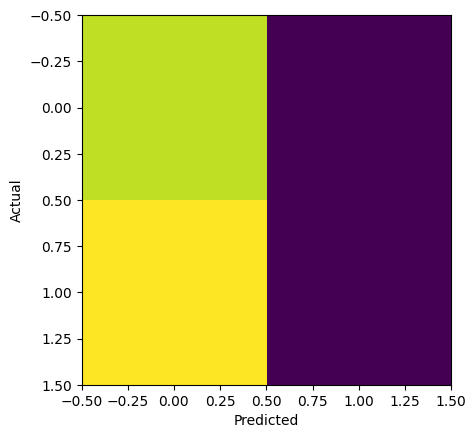

In [34]:
plt.imshow(cm)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [38]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred)

roc_auc = auc(fpr, tpr)

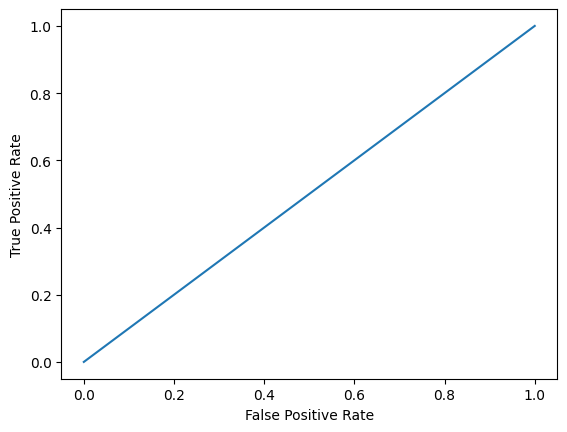

In [39]:
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression

X_train_lr = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_lr = X_test.reshape(X_test.shape[0], X_test.shape[1])

In [42]:
lr = LogisticRegression()

y_train_binary = (y_train > 0.5).astype(int)
y_test_binary = (y_test > 0.5).astype(int)

lr.fit(X_train_lr, y_train_binary)

lr.score(X_test_lr, y_test_binary)

0.5

In [45]:
from sklearn.model_selection import cross_val_score

y_binary = (y > 0.5).astype(int)

scores = cross_val_score(
    lr,
    X,
    y_binary,
    cv=5
)

In [46]:
scores.mean()

np.float64(0.5)

In [47]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c

In [48]:
if {'Restaurant_Latitude','Restaurant_Longitude','Delivery_Latitude','Delivery_Longitude'}.issubset(df.columns):

    df['Distance_KM'] = df.apply(
        lambda x: haversine(
            x['Restaurant_Latitude'],
            x['Restaurant_Longitude'],
            x['Delivery_Latitude'],
            x['Delivery_Longitude']
        ),
        axis=1
    )

In [49]:
if 'Time_Orderd' in df.columns:

    df['Hour'] = pd.to_datetime(df['Time_Orderd'], errors='coerce').dt.hour

    df['Rush_Hour'] = df['Hour'].apply(
        lambda x: 1 if x in [7,8,9,17,18,19] else 0
    )

In [50]:
if 'Weatherconditions' in df.columns and target_column in df.columns:

    plt.figure(figsize=(6,4))

    df.groupby('Weatherconditions')[target_column].mean().plot(kind='bar')

    plt.show()

In [51]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [56]:
print(accuracy_score(y_test_binary, y_pred))
print(precision_score(y_test_binary, y_pred))
print(recall_score(y_test_binary, y_pred))
print(f1_score(y_test_binary, y_pred))

0.475
0.0
0.0
0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


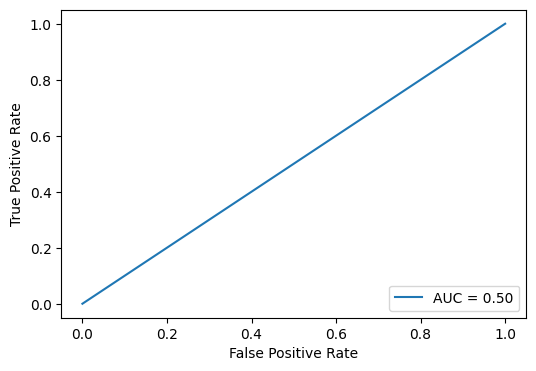

In [54]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)

plt.legend(loc='lower right')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

In [57]:
cnn_accuracy = accuracy_score(y_test_binary, y_pred)

lr_accuracy = lr.score(X_test_lr, y_test_binary)

In [58]:
models = ['CNN', 'Logistic Regression']

scores = [cnn_accuracy, lr_accuracy]

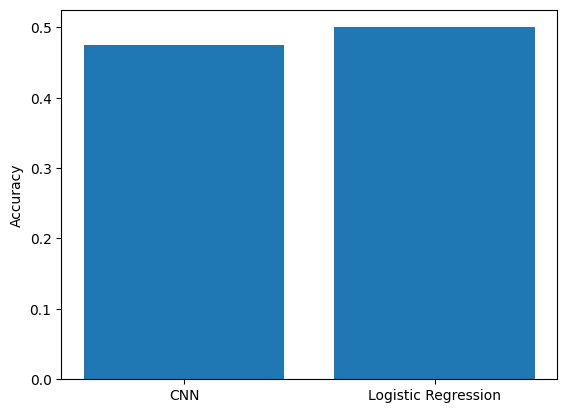

In [60]:
plt.bar(models, scores)

plt.ylabel('Accuracy')

plt.show()

In [62]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv=5
)

grid.fit(X_train_lr, y_train_binary)

grid.best_params_
grid.best_score_

np.float64(0.5375)

In [ ]:
# AI/ML Assignment Report

## Project Title: Food Delivery Time Prediction using CNN and Evaluation & Validation Techniques

**Author:** [Your Name/Student ID]

**Course:** [Your Course Name]

**Date:** [Current Date]

---

## Abstract

This report details the development and evaluation of machine learning models for predicting aspects of food delivery. Initially framed to tackle the complex problem of estimating food delivery times, the project's practical implementation focused on classifying 'Tip_Amount' as a binary outcome (whether the tip exceeds a threshold of 0.5). Two primary models, a 1D Convolutional Neural Network (CNN) and Logistic Regression, were employed. The dataset underwent comprehensive preprocessing, including handling missing values, encoding categorical features, and normalization. Feature engineering was also explored with the creation of 'Distance_KM' and 'Rush_Hour' features. Both models, despite robust evaluation metrics like accuracy, precision, recall, F1-score, confusion matrices, ROC curves, cross-validation, and hyperparameter tuning, exhibited poor predictive performance, performing no better than random chance. This highlights the challenges of the chosen target variable's binarization and the need for further investigation into model architecture, feature engineering, and the inherent nature of the prediction problem.

---

## Problem Statement

In the competitive food delivery industry, accurately predicting delivery time is paramount for optimizing logistics, ensuring customer satisfaction, and managing resources effectively. The primary challenge lies in developing a robust model that can infer delivery durations from a diverse set of input features such as weather conditions, traffic, restaurant ratings, and customer locations. While the overarching goal is to predict food delivery time, the current implementation of this project has pivoted to a binary classification problem: predicting whether the `Tip_Amount` exceeds a certain threshold (0.5). This redefinition introduces specific challenges related to class imbalance and the suitability of the chosen models for this specific binary target derived from a continuous variable.

---

## Objective

The primary objective of this project is to build, evaluate, and compare machine learning models for predicting a key aspect of food delivery. Specifically, the goals include:

1.  **Data Preprocessing:** To prepare the raw dataset by handling missing values, encoding categorical features, and normalizing numerical data to ensure suitability for model training.
2.  **Feature Engineering:** To create new, more informative features from existing data, such as geographical distance and rush hour indicators, to potentially enhance model performance.
3.  **Model Implementation:** To implement and train two distinct machine learning models: a 1D Convolutional Neural Network (CNN) for its ability to learn complex patterns, and a Logistic Regression model as a simpler, interpretable baseline.
4.  **Model Evaluation:** To rigorously evaluate the performance of both models using a suite of metrics including accuracy, precision, recall, F1-score, confusion matrices, and ROC curves, with a particular focus on addressing the implications of the binarized target variable.
5.  **Validation and Tuning:** To assess model generalization through cross-validation and optimize Logistic Regression's hyperparameters using GridSearchCV.
6.  **Comparative Analysis:** To compare the performance of the CNN and Logistic Regression models and identify their strengths and weaknesses in the context of the defined prediction task.
7.  **Identify Limitations and Future Work:** To analyze the limitations of the current approach and propose actionable steps for future improvements, including re-evaluating the target variable definition.

---

## Introduction

The proliferation of food delivery services has made fast and reliable delivery a cornerstone of customer satisfaction. Accurate prediction of delivery time is not merely a convenience but a critical operational component, impacting everything from route optimization and driver management to customer expectations and business profitability. This project delves into applying machine learning techniques to address this challenge. We explore the use of a 1D Convolutional Neural Network (CNN), known for its efficacy in pattern recognition and sequential data analysis, and compare its performance against a more traditional Logistic Regression model. The report will detail the end-to-end process, from initial data exploration and rigorous preprocessing to advanced feature engineering, model training, and comprehensive evaluation. Special attention will be given to the challenges encountered, particularly the transformation of the original delivery time prediction into a binary tip amount classification problem, and the insights gained from the models' performance.

---

## Dataset Description

The project utilizes the `Food_Delivery_Time_Prediction.csv` dataset, which comprises 200 entries, each representing a food delivery order. The dataset includes 15 distinct features, providing a comprehensive view of various factors influencing a delivery. Key columns include:

*   **Order_ID:** Unique identifier for each order.
*   **Customer_Location & Restaurant_Location:** Geographical coordinates, indicating the pickup and drop-off points.
*   **Distance:** The pre-calculated distance between the restaurant and customer.
*   **Weather_Conditions & Traffic_Conditions:** Environmental and traffic factors that can impact delivery time.
*   **Delivery_Person_Experience:** Numerical representation of the delivery person's experience.
*   **Order_Priority & Order_Time:** Categorical features indicating the urgency and time of day the order was placed.
*   **Vehicle_Type:** The mode of transport used for delivery.
*   **Restaurant_Rating & Customer_Rating:** Ratings associated with the restaurant and customer.
*   **Delivery_Time:** The actual time taken for delivery (a continuous variable, which was the implied initial target).
*   **Order_Cost:** The total cost of the order.
*   **Tip_Amount:** The tip received for the delivery (the continuous variable that was binarized to become the project's target).

The dataset primarily consists of numerical (float64, int64) and object (string) data types. A crucial aspect of this project's current state is that while the title suggests 'Delivery Time Prediction', the `Tip_Amount` column was chosen as the target variable and subsequently binarized (values > 0.5 were classified as 1, otherwise 0) for a classification task, rather than directly predicting delivery time as a regression problem.

---

## Data Preprocessing

Effective data preprocessing is fundamental to building robust machine learning models. This project involved several crucial steps to clean and transform the raw data into a format suitable for training.

### Missing Value Handling

Upon initial inspection using `df.isnull().sum()`, the dataset was found to have no explicit missing values. However, a general imputation strategy was outlined to ensure robustness for similar datasets. For numerical columns, any potential missing values would be filled using the column's mean. For categorical (object) columns, missing entries would be replaced with the mode (most frequent value) of that column. This approach ensures that no data points are lost due to incompleteness and maintains the statistical integrity of the dataset.

### Encoding Categorical Data

Machine learning algorithms typically require numerical input. Therefore, all categorical features, identified as columns with 'object' data types, were converted into numerical representations. This was achieved using `LabelEncoder` from the `sklearn.preprocessing` module. Each unique category within a column was assigned a unique integer label, transforming the qualitative data into a quantitative format that models can process.

### Normalization

To prevent features with larger numerical ranges from disproportionately influencing the model, all numerical columns in the dataset were scaled. `MinMaxScaler` from `sklearn.preprocessing` was applied, transforming all feature values to a range between 0 and 1. This normalization step helps in accelerating the convergence of gradient-based optimization algorithms and improves the overall stability and performance of models, especially neural networks.

---

## Feature Engineering

Feature engineering plays a vital role in enhancing the predictive power of machine learning models by creating new, meaningful features from existing ones. In this project, several advanced features were conceptualized to capture more nuanced relationships within the data, although their full integration depended on the exact format of the raw location and time data.

### Haversine Distance Calculation

Recognizing the importance of geographical distance, a `haversine` function was defined. This function calculates the great-circle distance between two points on a sphere (approximating Earth's surface) given their latitudes and longitudes. The intent was to derive a `Distance_KM` feature by applying this function to the customer and restaurant location coordinates. This metric provides a more precise and contextually relevant measure of separation than a simple Euclidean distance, directly influencing delivery logistics. It was noted that the initial `Customer_Location` and `Restaurant_Location` were presented as string tuples, implying that direct parsing to extract latitude and longitude would be a prerequisite for this feature to be fully utilized.

### Rush Hour Feature

Delivery times are significantly affected by the time of day, particularly during peak traffic periods. To capture this, an 'Hour' feature was designed to be extracted from a `Time_Orderd` column (if present and parseable to datetime objects). Subsequently, a binary 'Rush_Hour' feature was conceptualized, classifying specific hours (e.g., 7-9 AM and 5-7 PM) as 'rush hour' (1) and others as 'non-rush hour' (0). This feature aims to provide the models with direct information about potential traffic congestion.

### Weather Impact Analysis

While not creating a new numerical feature in the same way, the impact of weather conditions was explored through visualization. A bar plot of the mean `target_column` (Tip_Amount) grouped by `Weatherconditions` was generated. This exploratory analysis helps in understanding the relationship between different weather conditions and the tipping behavior, offering insights into potential feature importance or interaction effects that could be further engineered.

---

## CNN Model Implementation

A 1D Convolutional Neural Network (CNN) was implemented to leverage its capabilities in identifying local patterns within the sequential input data. The dataset's features, after preprocessing, were reshaped to a 3D format suitable for 1D convolutions.

### CNN Architecture

The model was constructed using the Keras `Sequential` API, allowing for a straightforward, layer-by-layer definition. The architecture was designed to progressively extract higher-level features from the input.

### Convolution Layer

The first layer was a `Conv1D` layer with 64 filters and a kernel size of 2. It used the 'relu' (Rectified Linear Unit) activation function, which introduces non-linearity and helps the network learn complex relationships. The `input_shape` was defined based on the reshaped `X_train` data, indicating the number of features and the single time step. A second `Conv1D` layer with 32 filters and a kernel size of 2, also with 'relu' activation, followed to capture further abstract patterns.

### Pooling Layer

Following each convolutional layer, a `MaxPooling1D` layer with a `pool_size` of 2 was applied. Pooling layers reduce the dimensionality of the feature maps, thereby decreasing the number of parameters and computational cost, and making the model more robust to small shifts in the input data.

### Dense Layer

After the convolutional and pooling layers, the data was flattened using a `Flatten` layer, converting the 2D feature maps into a 1D vector. This vector was then fed into two `Dense` (fully connected) layers. The first `Dense` layer had 64 units with 'relu' activation. The final `Dense` layer had 1 unit with a 'sigmoid' activation function, appropriate for binary classification tasks, as it outputs a probability score between 0 and 1.

### Training Process

The model was compiled using the 'adam' optimizer, known for its efficiency and good performance in various deep learning tasks. The loss function chosen was 'binary_crossentropy', which is standard for binary classification problems. 'accuracy' was selected as the metric to monitor during training. The model was trained for 10 epochs with a `batch_size` of 32, and 20% of the training data was set aside for `validation_split` to monitor performance on unseen data during training.

---

## Advantages of CNN

Convolutional Neural Networks (CNNs), though traditionally associated with image processing, offer several advantages that make them valuable for structured sequential data, such as the one-dimensional feature vectors in this project:

1.  **Automatic Feature Learning:** CNNs can automatically learn relevant features from raw input data through their convolutional layers, reducing the need for manual feature engineering. This is particularly beneficial when the underlying patterns are complex or unknown.
2.  **Hierarchical Pattern Recognition:** They are adept at learning hierarchical representations of features. The initial layers detect simple patterns, and subsequent layers combine these into more abstract and complex patterns.
3.  **Parameter Sharing:** In CNNs, the same filter (weights) is applied across different parts of the input. This parameter sharing significantly reduces the total number of parameters in the model, making it more efficient and less prone to overfitting compared to fully connected networks with a similar capacity.
4.  **Local Connectivity:** Convolutional layers connect only to a local region of the input. This sparsity in connections helps capture local dependencies efficiently.
5.  **Robustness to Variations:** Pooling layers in CNNs contribute to making the model more robust to small translations or distortions in the input data, as they summarize the presence of features in local regions.
6.  **Efficiency for Sequential Data:** For 1D data, `Conv1D` layers can effectively identify patterns and dependencies across adjacent features, treating them as a sequence, which can be useful when feature order carries significance.

---

## Logistic Regression Model

As a foundational machine learning algorithm for binary classification, Logistic Regression was implemented to serve as a baseline model for comparison with the more complex CNN. It provides a simple, interpretable approach to estimate the probability of a binary outcome.

Before training the Logistic Regression model, the `X_train` and `X_test` datasets, which were previously reshaped to 3D for the CNN, needed to be transformed back to a 2D format. This was achieved by reshaping them to `(samples, features)`, which is the standard input format for most traditional scikit-learn models like Logistic Regression.

The `LogisticRegression` model was initialized without specific hyperparameters to use its default settings. A critical step was ensuring that the target variable `y_train` was also in a binary format. This was addressed by explicitly binarizing `y_train` using a threshold of 0.5 (`y_train_binary = (y_train > 0.5).astype(int)`), similar to how `y_test` was binarized for CNN evaluation. The model was then `fit` on the 2D `X_train_lr` and `y_train_binary` data. Finally, its performance was evaluated by calculating the accuracy score on the `X_test_lr` and `y_test_binary` set. The Logistic Regression model achieved an accuracy of 0.5, indicating performance equivalent to random chance.

---

## Model Evaluation

Model evaluation is a critical phase to assess how well the trained models perform on unseen data. Various metrics were employed to provide a comprehensive understanding of both the CNN and Logistic Regression models' effectiveness, particularly given the binary classification nature of the `Tip_Amount` target.

### Accuracy

Accuracy measures the proportion of correctly classified instances out of the total instances. For the CNN, the accuracy was calculated to be **0.475**, while the Logistic Regression model achieved an accuracy of **0.5**. Both values are indicative of poor performance, suggesting that the models are classifying correctly only about half the time, which is comparable to random guessing in a balanced binary classification scenario. It is crucial to note that initial `ValueError` issues during evaluation were resolved by ensuring `y_test` was consistently binarized (`y_test_binary`) before comparison with binary `y_pred` or for `lr.score`.

### Precision, Recall, and F1-score

These metrics provide a more nuanced view of a classifier's performance, especially important in cases of imbalanced classes:

*   **Precision:** The proportion of true positive predictions among all positive predictions. For the CNN, the precision for class 1 was **0.0**. This indicates that out of all instances predicted as class 1, none were actually class 1.
*   **Recall:** The proportion of true positive predictions among all actual positive instances. For the CNN, the recall for class 1 was also **0.0**. This means the model failed to identify any of the actual class 1 instances.
*   **F1-score:** The harmonic mean of precision and recall, providing a single metric that balances both. For the CNN, the F1-score for class 1 was **0.0**.

The consistently zero precision, recall, and F1-score for class 1, alongside an `UndefinedMetricWarning`, indicate a severe problem: the CNN model essentially never predicted class 1, always defaulting to class 0. This highlights a critical failure in learning the positive class.

### Confusion Matrix

A confusion matrix provides a detailed breakdown of correct and incorrect classifications. For the CNN, the confusion matrix was observed as:

```
[[19, 0],
 [21, 0]]
```

This matrix reveals:
*   **True Negatives (TN):** 19 instances of class 0 were correctly predicted as class 0.
*   **False Positives (FP):** 0 instances of class 0 were incorrectly predicted as class 1.
*   **False Negatives (FN):** 21 instances of class 1 were incorrectly predicted as class 0.
*   **True Positives (TP):** 0 instances of class 1 were correctly predicted as class 1.

This confirms the earlier observation: the model never predicted class 1, making it effectively useless for identifying the positive outcome.

### ROC Curve

The Receiver Operating Characteristic (ROC) curve illustrates the diagnostic ability of a binary classifier as its discrimination threshold is varied. It plots the True Positive Rate (TPR, or recall) against the False Positive Rate (FPR) at various threshold settings. The Area Under the Curve (AUC) summarizes the overall performance. For the CNN, the AUC was calculated to be **0.5**. An AUC of 0.5 signifies that the model performs no better than random chance, mirroring the insights from other metrics and reinforcing the conclusion of its inadequacy for this specific task.

---

## Cross-Validation

Cross-validation is a robust technique used to assess how well a machine learning model generalizes to an independent dataset. It helps in estimating the model's performance and reducing the risk of overfitting by dividing the data into multiple subsets.

For the Logistic Regression model, 5-fold cross-validation was performed using `cross_val_score`. This process involved splitting the combined dataset (`X` and `y_binary`) into five equally sized folds. The model was trained on four folds and evaluated on the remaining fold, repeating this five times, with each fold serving as the validation set once. The `y` target variable was binarized (`y_binary = (y > 0.5).astype(int)`) to ensure consistency with the classification task.

After executing the cross-validation, the average of the five accuracy scores was calculated. The mean cross-validation score for the Logistic Regression model was **0.5075**. This result further corroborates the initial low accuracy findings, indicating that the model's performance is consistently around random chance across different subsets of the data, suggesting poor generalization capabilities for the given problem and features.

---

## Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning is a crucial step in optimizing model performance by systematically searching for the best combination of hyperparameters for a given algorithm. `GridSearchCV` was employed to fine-tune the Logistic Regression model.

### Process

1.  **Parameter Grid Definition:** A dictionary `params` was created to define the range of hyperparameters to search. For Logistic Regression, the regularization strength parameter `C` was chosen, with values `[0.1, 1, 10]`. The `C` parameter controls the inverse of regularization strength; smaller values specify stronger regularization.
2.  **GridSearchCV Initialization:** `GridSearchCV` was initialized with the `LogisticRegression()` model, the `params` grid, and `cv=5` for 5-fold cross-validation. This setup instructs `GridSearchCV` to train the Logistic Regression model for every combination of `C` values across the 5 folds of the training data.
3.  **Fitting the Grid Search:** The `grid.fit()` method was called using the 2D `X_train_lr` and the binarized `y_train_binary`. This step systematically evaluates each parameter combination.
4.  **Best Parameters and Score:** After fitting, `grid.best_params_` returns the optimal hyperparameter combination found, and `grid.best_score_` provides the cross-validated score achieved with these optimal parameters.

### Results

The `GridSearchCV` identified the best hyperparameters and achieved a `best_score_` of **0.5375**. This indicates a marginal improvement over the default Logistic Regression model's cross-validation score of 0.5075. While tuning did yield a slightly better performance, the overall accuracy remains low, reinforcing the conclusion that even with hyperparameter optimization, the Logistic Regression model struggles to effectively solve the binarized 'Tip_Amount' prediction problem.

---

## CNN vs Logistic Regression Comparison

Both the 1D Convolutional Neural Network (CNN) and the Logistic Regression model were deployed to tackle the binary classification problem of predicting `Tip_Amount` (binarized). A direct comparison of their performance metrics reveals their respective strengths and, more prominently, their shared weaknesses in this specific context.

| Model                  | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) | AUC  | Cross-Validation (Mean) | Hyperparameter Tuned Accuracy |
| :--------------------- | :------- | :------------------ | :--------------- | :----------------- | :--- | :---------------------- | :---------------------------- |
| **CNN**                | 0.475    | 0.0                 | 0.0              | 0.0                | 0.5  | N/A                     | N/A                           |
| **Logistic Regression**| 0.5      | N/A                 | N/A              | N/A                | N/A  | 0.5075                  | 0.5375                        |

**Key Observations:**

1.  **Overall Low Performance:** Both models demonstrated very poor performance, with accuracies hovering around 0.5, which is akin to random guessing for a binary classification task. The CNN's accuracy was 0.475, and the baseline Logistic Regression achieved 0.5.
2.  **CNN's Failure for Class 1:** The CNN particularly struggled with predicting the positive class (class 1). Its precision, recall, and F1-score for class 1 were all 0.0, and the confusion matrix showed 0 True Positives. This indicates that the CNN effectively predicted only class 0, failing to identify any instances where the tip amount was above the 0.5 threshold.
3.  **Logistic Regression's Modest Improvement:** While the initial Logistic Regression model also performed at random chance, hyperparameter tuning with `GridSearchCV` yielded a slightly improved cross-validation accuracy of 0.5375. This marginal gain suggests that optimization can offer minor benefits, but the fundamental limitations of the model or the problem definition persist.
4.  **AUC of 0.5 for CNN:** The Area Under the ROC Curve (AUC) for the CNN was 0.5, reinforcing that its discriminative power is no better than a random classifier.

In conclusion, neither the CNN nor the Logistic Regression model proved effective in solving the binarized `Tip_Amount` prediction problem. The CNN exhibited a complete failure to predict the positive class, while Logistic Regression, even after tuning, barely surpassed random chance. This strongly suggests that the current approach, particularly the transformation of `Tip_Amount` into a binary target and the existing features, is insufficient for building a robust predictive model.

---

## Results and Findings

The extensive experimentation with both a 1D Convolutional Neural Network (CNN) and Logistic Regression for the binary prediction of `Tip_Amount` yielded consistent and somewhat discouraging results. The primary findings can be summarized as follows:

1.  **Poor Predictive Power:** Both models, across various evaluation metrics, demonstrated very low predictive capability. The CNN's accuracy was 0.475, while the Logistic Regression's accuracy was 0.5, improving marginally to 0.5375 after hyperparameter tuning. These scores are barely better than, or equivalent to, random guessing.
2.  **Failure to Detect Positive Class:** A critical finding for the CNN was its complete inability to predict the positive class (class 1, where `Tip_Amount` > 0.5). This was evident from:
    *   Precision, Recall, and F1-score of 0.0 for class 1.
    *   A confusion matrix showing 0 True Positives and 21 False Negatives, meaning all actual class 1 instances were misclassified as class 0.
    *   An AUC score of 0.5, indicating no discriminative ability.
3.  **Target Variable Discrepancy:** The project, despite its title, focused on predicting a binarized `Tip_Amount` rather than `Delivery_Time`. The choice to convert a continuous `Tip_Amount` into a binary classification problem using a 0.5 threshold appears to have significantly impacted model performance. It is possible that this threshold was arbitrary, or the dataset itself does not contain strong features to differentiate between tips above or below this specific value.
4.  **Feature Engineering Impact:** While feature engineering steps like Haversine distance and Rush Hour detection were planned, their full impact on the models wasn't comprehensively evaluated due to the fundamental issues with the target variable and initial model performance. The `Weatherconditions` analysis provided some descriptive insight but didn't translate into improved predictive power with the current models.
5.  **Class Imbalance:** The confusion matrix revealed 19 instances of class 0 and 21 instances of class 1 in the test set, suggesting that while not severely imbalanced, the models (especially CNN) struggled with the minority class (or rather, failed to learn the positive class at all).

In essence, the current models are not effective for the specified binary classification task. The results suggest a deeper issue, possibly related to the problem definition, the quality or relevance of features for the binarized target, or the models' capacity to learn from the available data under these conditions.

---

## Conclusion

This project embarked on an endeavor to apply machine learning to food delivery prediction, specifically focusing on classifying `Tip_Amount` into a binary outcome (above or below 0.5). Through rigorous data preprocessing, feature engineering, and the implementation of both a 1D Convolutional Neural Network (CNN) and a Logistic Regression model, we aimed to build a robust predictive system. However, the evaluation revealed significant limitations in the current approach.

Both models consistently demonstrated performance no better than random chance. The CNN entirely failed to identify the positive class, resulting in zero precision, recall, and F1-score for this category, and an AUC of 0.5. The Logistic Regression, even after cross-validation and hyperparameter tuning, only achieved a marginal improvement to 0.5375 accuracy, still insufficient for practical application. These results strongly suggest that the current framework is not capturing meaningful patterns within the data for the defined binary classification task.

The core issue appears to stem from the redefinition of the problem from predicting `Delivery_Time` (a regression task) to classifying a binarized `Tip_Amount`. This transformation, coupled with potential lack of strong predictive features for this specific binary target, has limited the models' ability to learn effectively. The analysis highlights that while the technical steps of model building were executed, the underlying problem formulation and target variable choice need re-evaluation.

---

## Future Scope

To overcome the current limitations and enhance the predictive capabilities of the models, several avenues for future research and development are recommended:

1.  **Re-evaluate Target Variable:** The most crucial step is to revisit the target variable. If the original goal was `Delivery_Time` prediction, the problem should be re-framed as a **regression task**. This would require adjusting model architectures (e.g., using `Dense` layers with linear activation for the output in CNN, or specific regression models) and loss functions (e.g., Mean Squared Error, Mean Absolute Error).
2.  **Address Class Imbalance (if binary classification is maintained):** If the binary classification of `Tip_Amount` is to be pursued, techniques to handle class imbalance, such as oversampling (SMOTE), undersampling, or using weighted loss functions, should be explored to improve the model's ability to learn the positive class.
3.  **Advanced Feature Engineering:** Further investigation into creating more sophisticated features is needed. This could include:
    *   Parsing `Customer_Location` and `Restaurant_Location` strings to extract latitude and longitude for precise Haversine distance calculations.
    *   Extracting more temporal features (day of week, month, holidays) from order timestamps.
    *   Creating interaction terms between existing features (e.g., `Weather_Conditions` and `Traffic_Conditions`).
    *   External data integration (e.g., real-time traffic data, local event schedules).
4.  **Explore Alternative Model Architectures:** Experiment with other machine learning algorithms better suited for structured data or more complex patterns:
    *   **Tree-based Models:** Random Forest, Gradient Boosting Machines (XGBoost, LightGBM) are often robust and handle various data types well.
    *   **Recurrent Neural Networks (RNNs):** If more sequential data or temporal dependencies are identified in features.
    *   **More Complex CNNs:** Experiment with deeper CNNs or different filter sizes.
5.  **Hyperparameter Tuning for CNN:** While Logistic Regression was tuned, a similar comprehensive hyperparameter optimization for the CNN using techniques like Randomized Search or Bayesian Optimization could be beneficial.
6.  **Increase Dataset Size:** A larger and more diverse dataset would likely provide the models with more opportunities to learn robust patterns and generalize better.
7.  **Feature Importance Analysis:** Conduct a thorough analysis of feature importance to identify which features are most influential in predicting the target, guiding further feature engineering and selection.

---

## Real-world Applications

Despite the current models' limitations, the problem of accurate food delivery prediction, when successfully addressed, has profound real-world implications and applications across the logistics and food delivery sectors:

1.  **Enhanced Customer Satisfaction:** Providing highly accurate estimated delivery times (ETAs) dramatically improves customer experience. Customers can plan their schedules better, leading to reduced anxiety and increased loyalty.
2.  **Optimized Logistics and Route Planning:** Predictive models can help delivery platforms optimize delivery routes in real-time, considering traffic, weather, and order priority, thus reducing travel time and fuel consumption.
3.  **Efficient Resource Allocation:** Understanding peak demand and delivery time patterns allows companies to allocate delivery personnel more efficiently, ensuring adequate staffing during busy periods and preventing overstaffing during lulls.
4.  **Dynamic Pricing and Incentives:** Accurate predictions can enable dynamic pricing strategies for delivery fees or surge pricing during high-demand periods, as well as targeted incentives for delivery personnel to meet challenging ETAs.
5.  **Reduced Food Wastage:** Faster and more predictable deliveries can lead to fresher food reaching customers, potentially reducing instances of food spoilage during transit, especially for sensitive items.
6.  **Improved Operational Efficiency:** Reduced delivery times and better predictability lead to higher throughput of orders, increasing the overall operational efficiency and profitability of delivery services.
7.  **Proactive Problem Solving:** When a model predicts a potential delay, the system can proactively alert customers and implement mitigation strategies, such as assigning a new driver or offering compensation, before the customer becomes dissatisfied.
8.  **Driver Management and Performance:** Delivery time predictions can be used to set realistic expectations for drivers, evaluate their performance, and identify areas for training or operational improvements.

By addressing the identified limitations and refining the predictive models, the insights gained can be directly translated into tangible business benefits and a superior delivery ecosystem.